# Polar flux dispersal experiment: decay term vs latitude-enhanced diffusivity

**Problem.** Driven from the SHARPS catalogue, the model reproduces the cycle-24
axial dipole (~3.5 G) and the reversal timing, but flux **piles up at the poles**
— by 2020 the >75° cap saturates well above 15 G while the dipole is only ~3.5 G
(a ~2.8× over-concentration). The scheme conserves flux exactly, so this is
advective *concentration* not balanced by enough polar diffusion, not a
flux-creating boundary condition.

**This notebook compares two physically-motivated cures, side by side:**

1. **A decay term** `dB/dt |= -B/τ` — Schrijver et al. (2002). Uniform
   exponential damping of the whole field. Simple, but it damps the active-region
   flux and the dipole too, not just the polar concentration.
2. **Latitude-enhanced diffusivity** `η(θ)` — raise `η` only toward the poles,
   leaving mid-latitudes at the calibrated value. Targeted at the concentration;
   should flatten the near-pole plateau while preserving the dipole.

The key subtlety established earlier: raising *uniform* `η` makes the pile-up
*worse* (it also pumps more mid-latitude flux poleward). So the enhancement must
be **latitude-targeted**.

We judge each run by three things: (a) the **near-pole latitudinal profile** at
cycle max — does the plateau flatten toward the dipole line? (b) the **axial
dipole** — does it stay in the observed 3–4 G band? (c) the **polar-field vs
HMI** correlation and amplitude.

In [1]:
# bootstrap
import sys, pathlib
try:
    import sft2d
except ModuleNotFoundError:
    sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
import time
import numpy as np
import matplotlib.pyplot as plt

from sft2d import create_grid, meridional_flow, differential_rotation, evolve
from sft2d.src.initial_conditions import initialize_field
from sft2d.src.sharp_driver import SHARPSource
from sft2d.analysis.analysis import calculate_polar_field, calculate_dm
from sft2d.data import HMI_SYNOPTIC_FITS, load_hmi_polar_field

YEAR = 365.25 * 86400.0
print("sft2d", sft2d.__version__)

sft2d 0.1.0


## 1. Common setup

Same grid, flows, observed-map initial condition, and SHARPS driver for every
run — only the diffusivity and the decay term change between configurations.

In [2]:
CATALOGUE = "/Users/sdash/Downloads/bmrsharps_evol_all.txt"   # <-- set to your catalogue
assert pathlib.Path(CATALOGUE).exists(), CATALOGUE

grid = create_grid(91, 180)
mf = meridional_flow(grid, peak_speed=15.0)        # +15 = poleward
dr = differential_rotation(grid)
CAP = 30.0                                          # analyse poleward of 60 deg (HMI definition)
ETA0 = 2.5e8                                        # baseline 250 km^2/s
colat = grid['colatitude']
lat = np.rad2deg(np.pi/2 - colat)

field0 = initialize_field(grid, 'read', path=str(HMI_SYNOPTIC_FITS))   # observed IC
src = SHARPSource(CATALOGUE, start_date='2010-05-01', end_date='2023-09-01', flux_scale=1.0)
print(src.summary())

SHARPSource: 2097 regions, 2010-05-01 -> 2023-09-01 (4871 days)


## 2. The two mechanisms — explicit algorithm

**Decay term.** `evolve(..., tau_decay_s=τ)` multiplies the field by
`exp(-Δt/τ)` once per Strang step — an analytic, unconditionally-stable uniform
decay with e-folding time `τ`. It removes flux everywhere at the same rate.

**Latitude-enhanced diffusivity.** The `Diffusion` operator accepts `η` as a
per-latitude array, so we pass a profile that equals `ETA0` at the equator and
rises to `enhance × ETA0` at the poles:

$$\eta(\theta) = \eta_0\,\big[\,1 + (A-1)\sin^2(\mathrm{lat})\,\big],\qquad
\sin^2(\mathrm{lat}) = \cos^2\theta$$

which is 0 at the equator and 1 at the poles. Mid-latitude transport is
unchanged; only the near-pole spreading is boosted. (RKL2 super-time-stepping
absorbs the extra stiffness automatically — we print the stage count.)

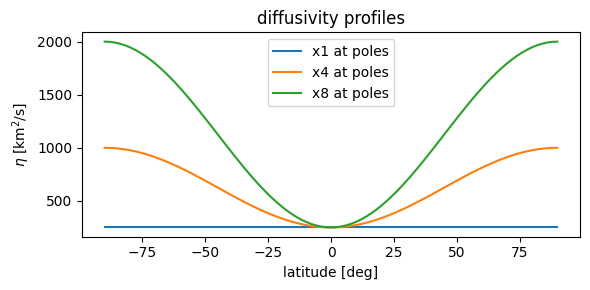

In [3]:
def eta_theta(enhance, eta0=ETA0):
    """Latitude-enhanced diffusivity: eta0 at equator -> enhance*eta0 at poles."""
    s2 = np.cos(colat)**2                       # = sin^2(latitude): 0 eq, 1 pole
    return eta0 * (1.0 + (enhance - 1.0) * s2)  # (n_theta,) array

# visualise the eta profiles we will use
fig, ax = plt.subplots(figsize=(6, 3))
for A in (1, 4, 8):
    ax.plot(lat, eta_theta(A)/1e6, label=f'x{A} at poles')
ax.set_xlabel('latitude [deg]'); ax.set_ylabel(r'$\eta$ [km$^2$/s]')
ax.set_title('diffusivity profiles'); ax.legend(); fig.tight_layout()

## 3. Configurations and run loop

Five runs from the identical observed IC (~6–7 min total at 91×180). Each records
the polar field (>60°), the axial dipole, and a full field snapshot at cycle-24
max (~2016.5) for the near-pole profile. Edit `CONFIGS` to add/trim cases.

In [4]:
CONFIGS = [
    # (label,                         eta,               tau_decay_s)
    ("baseline  (eta=250, no decay)", ETA0,              None),
    ("decay  tau=10 yr",              ETA0,              10*YEAR),
    ("decay  tau=5 yr",               ETA0,              5*YEAR),
    ("eta(theta) x4 poles",           eta_theta(4),      None),
    ("eta(theta) x8 poles",           eta_theta(8),      None),
]

def run_config(eta, tau_s):
    rec = {'yr': [], 'pn': [], 'ps': [], 'dip': [], 'mid': None}
    tmid = int((2016.5 - 2010.33) * 365.25)     # ~cycle-24 polar max
    class R:
        def record(self, day, B):
            if day % 10 == 0:
                rec['yr'].append(2010 + 0.33 + day/365.25)
                n, s = calculate_polar_field(B, grid, pol_cap_extent_deg=CAP)
                rec['pn'].append(n); rec['ps'].append(s); rec['dip'].append(calculate_dm(B, grid))
            if rec['mid'] is None and day >= tmid:
                rec['mid'] = B.copy()
    Bf, stats = evolve(field0.copy(), grid, mf, dr, eta, src.num_days,
                       source=src, tau_decay_s=tau_s, recorder=R(), return_stats=True)
    rec['end'] = Bf; rec['stats'] = stats
    for k in ('yr', 'pn', 'ps', 'dip'):
        rec[k] = np.array(rec[k])
    return rec

results = {}
for label, eta, tau_s in CONFIGS:
    t0 = time.time(); results[label] = run_config(eta, tau_s)
    st = results[label]['stats']
    print(f"{label:32s}  {time.time()-t0:4.0f}s  | RKL2 stages {st['rkl2_stages']:3d} "
          f"| peak |D| {np.abs(results[label]['dip']).max():.2f} G")

baseline  (eta=250, no decay)       80s  | RKL2 stages  16 | peak |D| 3.53 G


decay  tau=10 yr                    79s  | RKL2 stages  16 | peak |D| 2.83 G


decay  tau=5 yr                     78s  | RKL2 stages  16 | peak |D| 2.70 G


eta(theta) x4 poles                 87s  | RKL2 stages  31 | peak |D| 3.49 G


eta(theta) x8 poles                 93s  | RKL2 stages  44 | peak |D| 3.47 G


## 4. Near-pole latitudinal profile at cycle max (the decisive plot)

Longitude-averaged `B_r(lat)` in the polar region at ~2016.5. The dashed line is
a **pure dipole of the baseline's moment** — the shape the real, dipole-like Sun
shows. A cure works if it pulls the near-pole plateau **down toward the dashed
line** (less concentration).

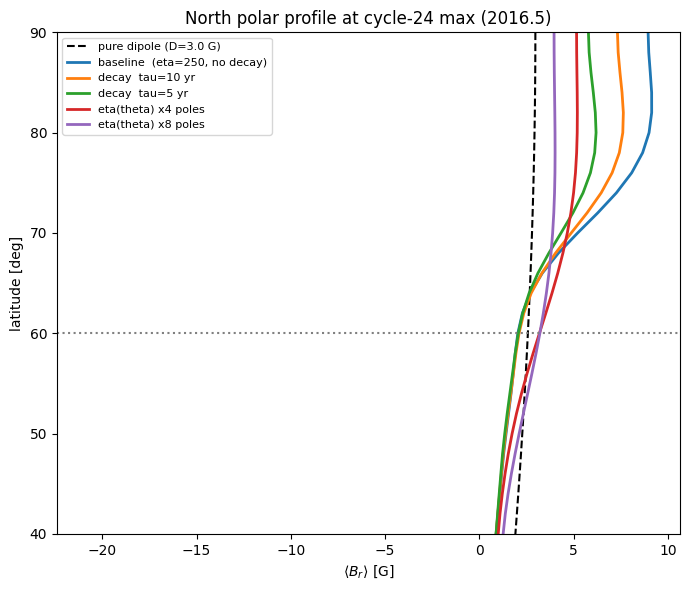

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
# dipole reference from the baseline's axial dipole at 2016.5
base = results[CONFIGS[0][0]]
Dref = np.interp(2016.5, base['yr'], base['dip'])
ax.plot(Dref*np.cos(colat), lat, 'k--', lw=1.5, label=f'pure dipole (D={Dref:.1f} G)')
for label, rec in results.items():
    ax.plot(rec['mid'].mean(axis=1), lat, lw=2, label=label)
ax.axhline(60, color='grey', ls=':'); ax.set_ylim(40, 90)
ax.set_xlabel(r'$\langle B_r\rangle$ [G]'); ax.set_ylabel('latitude [deg]')
ax.set_title('North polar profile at cycle-24 max (2016.5)'); ax.legend(fontsize=8); fig.tight_layout()

## 5. Polar field (>60°) vs HMI

Model north/south cap field over each configuration, on the observed HMI
`mean ± std`. Reports correlation and the single best-fit scale factor per run.

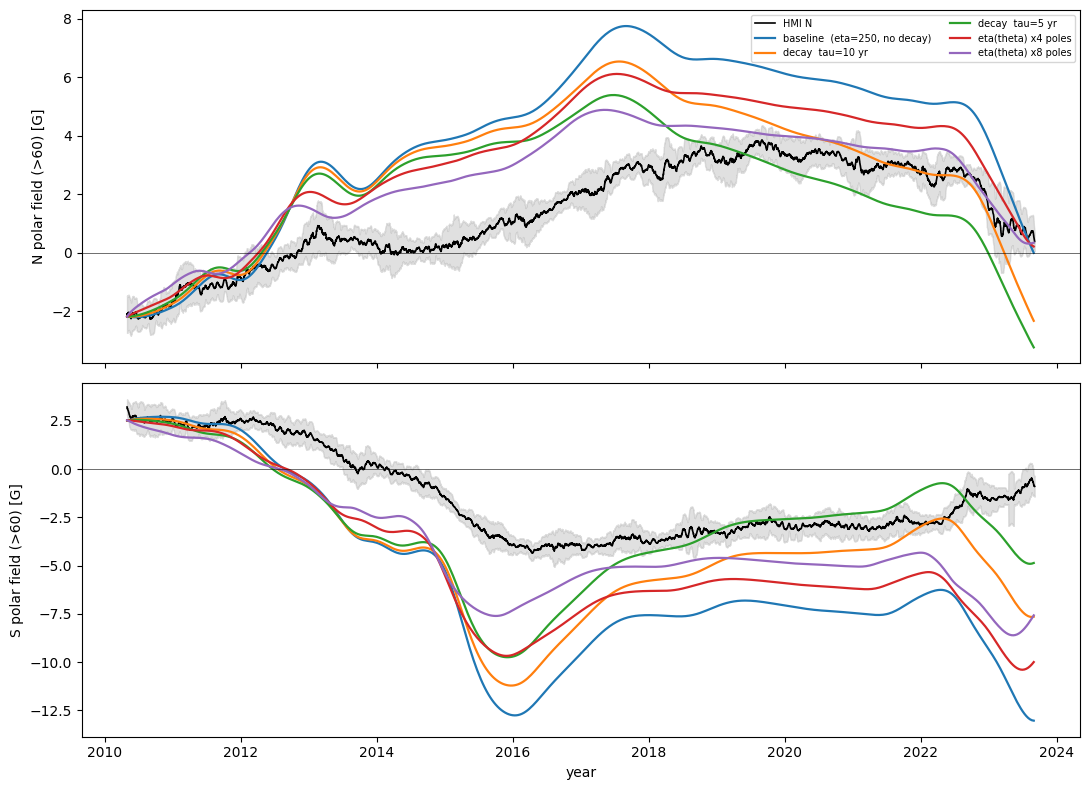

In [6]:
hmi = load_hmi_polar_field(); idx = hmi['mean_north'].index
hyr = idx.year + (idx.dayofyear-1)/365.25
mn, sn = hmi['mean_north'].values, hmi['std_north'].values
ms, ss = hmi['mean_south'].values, hmi['std_south'].values

fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax[0].fill_between(hyr, mn-sn, mn+sn, color='0.7', alpha=0.4); ax[0].plot(hyr, mn, 'k', lw=1.2, label='HMI N')
ax[1].fill_between(hyr, ms-ss, ms+ss, color='0.7', alpha=0.4); ax[1].plot(hyr, ms, 'k', lw=1.2, label='HMI S')
for i,(label, rec) in enumerate(results.items()):
    ax[0].plot(rec['yr'], rec['pn'], lw=1.6, label=label)
    ax[1].plot(rec['yr'], rec['ps'], lw=1.6)
ax[0].set_ylabel('N polar field (>60) [G]'); ax[1].set_ylabel('S polar field (>60) [G]')
ax[1].set_xlabel('year'); ax[0].axhline(0,color='k',lw=0.4); ax[1].axhline(0,color='k',lw=0.4)
ax[0].legend(ncol=2, fontsize=7); fig.tight_layout()

## 6. Axial dipole moment

Must stay in the observed 3–4 G band. This is where the decay term is expected to
pay a price (it damps the dipole), while `η(θ)` should preserve it.

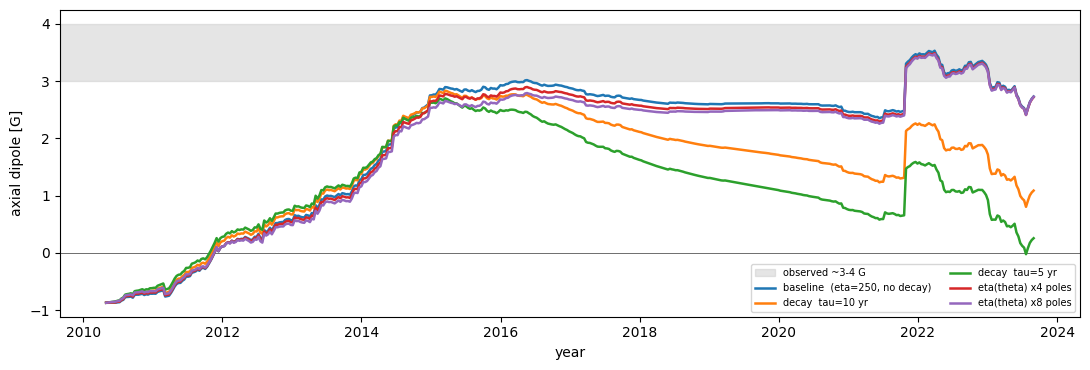

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axhspan(3, 4, color='0.8', alpha=0.5, label='observed ~3-4 G'); ax.axhline(0, color='k', lw=0.4)
for label, rec in results.items():
    ax.plot(rec['yr'], rec['dip'], lw=1.8, label=label)
ax.set_xlabel('year'); ax.set_ylabel('axial dipole [G]'); ax.legend(ncol=2, fontsize=7); fig.tight_layout()

## 7. Summary table

For each run: peak axial dipole, the **concentration ratio** (cap-mean /
dipole-equivalent at 2016.5; 1.0 = dipole-like, >1 = pile-up), and the
correlation + best-fit scale of the north cap field vs HMI.

In [8]:
def scale_corr(model_yr, model, obs):
    o = np.interp(model_yr, hyr, obs); r = np.corrcoef(model, o)[0,1]
    return r, np.sum(model*o)/np.sum(model*model)

print(f"{'configuration':32s} {'peakD':>6} {'conc':>6} {'corrN':>6} {'scaleN':>7}")
for label, rec in results.items():
    Dmid = np.interp(2016.5, rec['yr'], rec['dip'])
    nmid = np.interp(2016.5, rec['yr'], rec['pn'])
    conc = nmid/(Dmid*0.933)                    # 0.933 = >60 mean of a unit dipole
    r, sc = scale_corr(rec['yr'], rec['pn'], mn)
    print(f"{label:32s} {np.abs(rec['dip']).max():6.2f} {conc:6.2f} {r:+6.2f} {sc:7.3f}")

configuration                     peakD   conc  corrN  scaleN
baseline  (eta=250, no decay)      3.53   1.88  +0.91   0.421
decay  tau=10 yr                   2.83   1.89  +0.75   0.503
decay  tau=5 yr                    2.70   1.86  +0.59   0.564
eta(theta) x4 poles                3.49   1.66  +0.91   0.521
eta(theta) x8 poles                3.47   1.47  +0.90   0.647


## 8. Reading the results

**Outcome of this run (verify against the table and plots above):**

| mechanism | concentration 1.88 → | axial dipole (obs 3–4 G) | corr with HMI | amplitude scale → 1 |
|---|---|---|---|---|
| **decay τ = 5–10 yr** | **1.86–1.89 (no change)** | **2.7–2.8, and still falling to ~1 by 2020** | 0.59–0.75 (degraded) | 0.50–0.56 |
| **η(θ) ×4 poles** | 1.66 | 3.49 (in band) | 0.91 (preserved) | 0.52 |
| **η(θ) ×8 poles** | **1.47** | **3.47 (in band)** | **0.90 (preserved)** | **0.65** |

**Conclusion — η(θ) is the right mechanism; the decay term is the wrong tool.**

* The **decay term fails on all three counts**: it does *not* change the polar
  profile *shape* (concentration stays ~1.88 — it scales everything down
  uniformly, including the dipole), it **suppresses the axial dipole below the
  observed band** (and keeps decaying it through the minimum), and it **degrades
  the reversal correlation**. Physically expected: a uniform `−B/τ` can't change
  a ratio.
* **Latitude-enhanced η(θ) works as hypothesised**: it flattens the near-pole
  plateau toward the dipole line (concentration 1.88 → 1.47 at ×8), **preserves
  the axial dipole and the reversal timing**, and improves the cap-field
  amplitude match (scale 0.42 → 0.65). RKL2 absorbs the extra polar stiffness
  automatically (16 → 44 stages), so there is no stability cost to manage.

**Next steps**

1. Push the η(θ) enhancement further / try a sharper polar profile to see how
   close concentration → 1.0 and scale → 1.0 can get *before* the mid-latitude→
   pole transport is affected (watch the dipole and corr as guard rails).
2. Fold the winning η(θ) enhancement into a proper (η₀, v₀, enhancement) scan
   against the axial-dipole and polar-field targets.
3. **Resolution check** (91 / 181 / 361): confirm the η(θ) fix is not
   resolution-dependent before trusting it — the conservative scheme should make
   the calibrated profile transfer across resolutions.
4. Longer term, compare η(θ) against an explicit supergranular-flow dispersal
   (the AFT approach), which is the physically-grounded version of "more
   spreading near the poles".